Import Labraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings

<function warnings.filterwarnings(action, message='', category=<class 'Warning'>, module='', lineno=0, append=False)>

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import *

In [3]:
!pip install tensorflow

import tensorflow

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

Load Dataset

In [4]:
data = pd.read_csv('House Price Prediction Dataset.csv')
df = pd.DataFrame(data)

Check Top 50 records

In [5]:
df.head(50)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
5,6,3944,1,2,1,1906,Urban,Poor,No,93262
6,7,3671,1,1,2,1948,Rural,Poor,Yes,448722
7,8,3419,2,4,1,1925,Suburban,Good,Yes,594893
8,9,630,2,2,1,1932,Rural,Poor,Yes,652878
9,10,2185,3,3,1,2000,Downtown,Poor,No,340375


Check Bottom top 50 records

In [6]:
df.tail(50)

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
1950,1951,1093,2,1,1,2023,Downtown,Poor,No,153845
1951,1952,4304,5,4,3,1939,Suburban,Poor,Yes,362130
1952,1953,1959,5,3,1,1944,Urban,Good,Yes,387540
1953,1954,3993,3,2,1,1967,Rural,Good,No,891610
1954,1955,3101,3,3,1,1908,Suburban,Poor,No,847177
1955,1956,2944,1,3,3,2004,Suburban,Excellent,No,828520
1956,1957,3172,5,2,1,1921,Suburban,Fair,No,303730
1957,1958,4700,3,3,1,1917,Rural,Good,Yes,253426
1958,1959,516,2,3,1,1975,Urban,Fair,No,916069
1959,1960,3691,4,1,2,2005,Downtown,Poor,Yes,972532


Basic Data Understanding

In [7]:
df.shape

(2000, 10)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [9]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


Check missing values

In [10]:
df.isnull().sum()/len(df)*100

,0
Id,0.0
Area,0.0
Bedrooms,0.0
Bathrooms,0.0
Floors,0.0
YearBuilt,0.0
Location,0.0
Condition,0.0
Garage,0.0
Price,0.0


In [11]:
df = df.drop(columns='Id')

Check duplicates

In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates()

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3592,2,2,3,1938,Downtown,Good,No,266746
3,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,4926,1,4,2,1975,Downtown,Fair,Yes,636056
...,...,...,...,...,...,...,...,...,...
1995,4994,5,4,3,1923,Suburban,Poor,No,295620
1996,3046,5,2,1,2019,Suburban,Poor,Yes,580929
1997,1062,5,1,2,1903,Rural,Poor,No,476925
1998,4062,3,1,2,1936,Urban,Excellent,Yes,161119


Outlier Detection

In [14]:
col_num = df.select_dtypes(include='number')
col_num

,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
0,1360,5,4,3,1970,149919
1,4272,5,4,3,1958,424998
2,3592,2,2,3,1938,266746
3,966,4,2,2,1902,244020
4,4926,1,4,2,1975,636056
...,...,...,...,...,...,...
1995,4994,5,4,3,1923,295620
1996,3046,5,2,1,2019,580929
1997,1062,5,1,2,1903,476925
1998,4062,3,1,2,1936,161119


Box plot

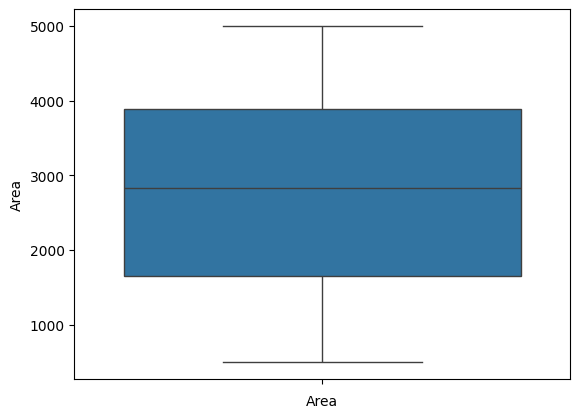

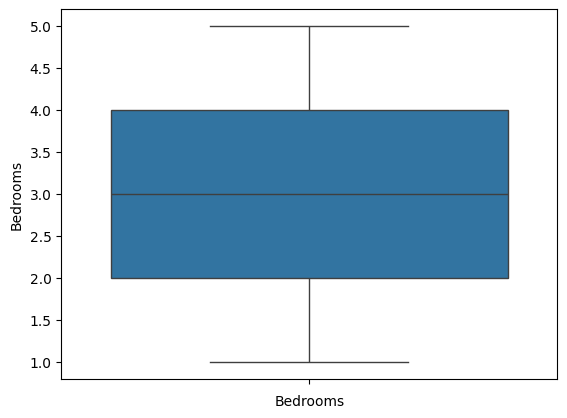

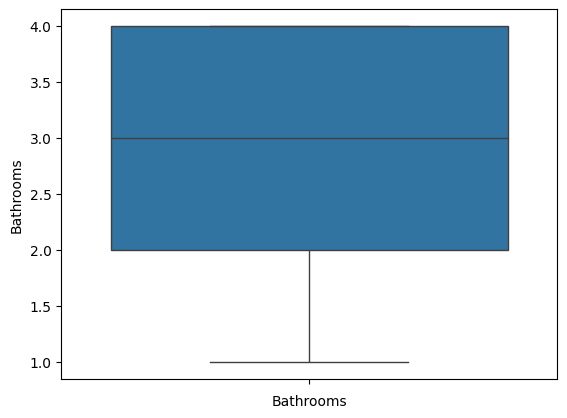

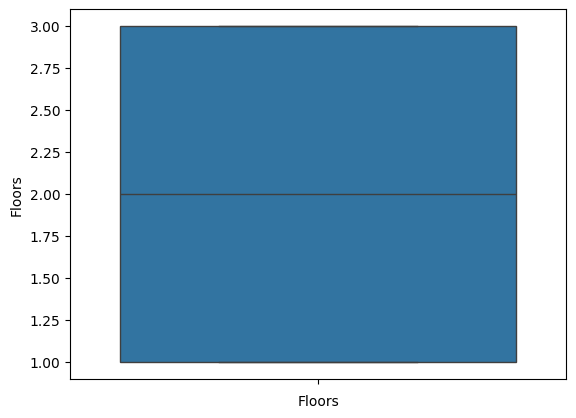

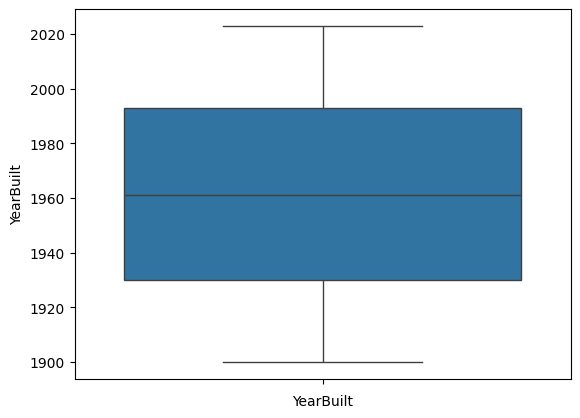

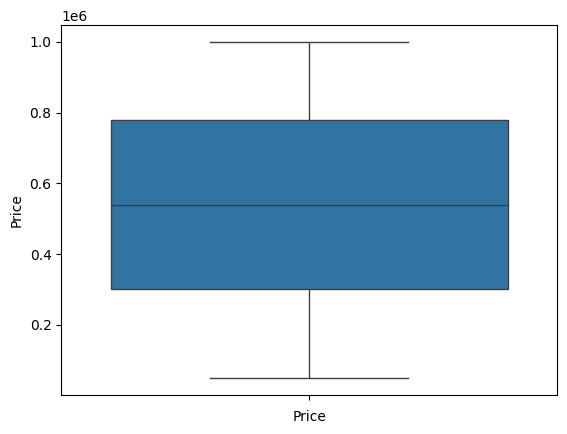

In [15]:
for i in col_num.columns:

  sns.boxplot(df[i])
  plt.xlabel(i)
  plt.show()

Data Preprocessing

In [16]:
LE = LabelEncoder()

In [17]:
col_obj = df.select_dtypes(include='object')

In [18]:
for i in col_obj.columns:
  df[i] = LE.fit_transform(df[i])

In [19]:
df.isnull().sum()

,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


Split Features and Target

In [20]:
x = df.drop(columns='Price')
y = df['Price']

In [21]:
x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42, test_size=0.2)

Standard Scaler

In [22]:
SS = StandardScaler()

In [23]:
x_train = SS.fit_transform(x_train)
x_test = SS.transform(x_test)

Build ANN Model

In [24]:
ANN = Sequential([
    # input layer
    Dense(1000, activation='relu', input_dim = x_train.shape[1]), # input_dim = 9
    # hidden layer
    Dense(500, activation='relu'),
    # hidden layer
    Dense(32, activation='relu'),
    Dropout(0.2),
    # output layer
    Dense(1)  # ❗ No activation (linear by default)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


**You are bringing tools:**

*  Sequential → to build the brain layer by layer
*  Dense → a group of neurons (like brain cells)
*  Dropout → helps prevent overlearning (like forgetting some things on purpose)

Compile model

In [25]:
ANN.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)

In [26]:
ANN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1000)           │         9,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 500)            │       500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │        16,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 525,565 (2.00 MB)

 Trainable params: 525,565 (2.00 MB)

 Non-trainable params: 0 (0.00 B)

Early Stopping

In [27]:
early_stop = EarlyStopping(
    monitor = 'val_loss',
    patience = 10,
    restore_best_weights = True
)


Train Model

In [28]:
history = ANN.fit(
    x_train, y_train,
    verbose = 1,
    validation_split = 0.2,
    epochs = 200,
    batch_size = 32,
    callbacks = [early_stop]
)

Epoch 1/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 366936653824.0000 - mae: 538415.5625 - val_loss: 348989161472.0000 - val_mae: 526533.6875
Epoch 2/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - loss: 365081001984.0000 - mae: 536680.9375 - val_loss: 344380866560.0000 - val_mae: 522152.7500
Epoch 3/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 353357168640.0000 - mae: 525655.3750 - val_loss: 322580709376.0000 - val_mae: 500877.8125
Epoch 4/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 313212600320.0000 - mae: 486007.5625 - val_loss: 262803685376.0000 - val_mae: 439205.9375
Epoch 5/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - loss: 230877691904.0000 - mae: 401836.6250 - val_loss: 164005085184.0000 - val_mae: 333390.3125
Epoch 6/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 133213437952.0000 - mae: 300067.7812 - val_loss: 86818832384.0000 - val_mae: 248572.3438
Epoch 7/200
40/40 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 86658195456.0000 - mae: 250757.5000 - val

Model Evaluation

In [29]:
y_pred = ANN.predict(x_test)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


In [30]:
mse = mean_squared_error(y_pred, y_test)
mse

82371043328.0

In [31]:
rmse = np.sqrt(mse)
rmse

np.float64(287003.5597828013)

In [32]:
r2 = r2_score(y_test, y_pred)
r2

-0.05876970291137695

 Plot Training History

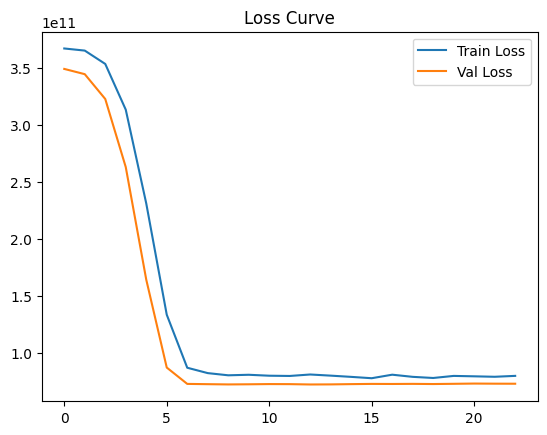

In [33]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()


In [34]:
def pred(Area, Bedrooms, Bathrooms, Floors, YearBuilt, Location, Condition, Garage):
  features = np.array([[Area, Bedrooms, Bathrooms, Floors, YearBuilt, Location, Condition, Garage]])
  features_scale = SS.fit_transform(features)
  result = ANN.predict(features_scale).reshape(1,-1)
  return result[0]

In [35]:
Area = 2463
Bedrooms = 8
Bathrooms = 3
Floors = 5
YearBuilt = 1974
Location = 3
Condition = 2
Garage = 1

price = pred(Area, Bedrooms, Bathrooms, Floors, YearBuilt, Location, Condition, Garage)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


In [36]:
price

array([387220.44], dtype=float32)

Save Model

In [37]:
ANN.save('ann_model.h5')

In [38]:
import joblib
joblib.dump(SS, "scaler.pkl")

['scaler.pkl']

check verison and install the same in pycharm

In [39]:
import tensorflow as tf
import sklearn
import keras

In [40]:
print(tf.__version__)
print(sklearn.__version__)
print(keras.__version__)

2.19.0
1.6.1
3.13.2
